# Load libraries and functions

In [1]:
suppressPackageStartupMessages({
library(Seurat)
library(scCustomize)
library(spatula)
library(ComplexHeatmap)
    library(rcna)
    library(circlize)
    library(ggrastr)
    library(tidyverse)
    library(scico)
    library(circlize)    
    library(ggsci)
    })

In [2]:
library(ggrastr)

In [3]:
get_theme <- function(size=12, angle=45) {
    defined_theme = theme_bw(base_size=size) + theme(legend.title=element_blank(), strip.text=element_text(size=size), legend.text=element_text(size=size), axis.title.x=element_text(size=size), axis.title.y=element_text(size=size), axis.text.y=element_text(size=size), axis.text.x=element_text(size=size, angle=angle, hjust = 1, vjust=1.05), legend.position="bottom", legend.box = "horizontal")
    defined_theme
}

fig.size <- function(h, w) {
    options(repr.plot.height = h, repr.plot.width = w)
}

# Configure colors

In [4]:
heatmap_col_fun <- colorRamp2(c(-2, 0, 2), scico(3, palette = "vik"))  # "vik" is diverging

niche_cols = pal_npg("nrc")(9)
niche_cols

[1] "#E64B35FF" "#4DBBD5FF" "#00A087FF" "#3C5488FF" "#F39B7FFF" "#8491B4FF"
[7] "#91D1C2FF" "#DC0000FF" "#7E6148FF"

In [5]:
celltype_colors <- c(
    # cell groups
  "T" = "#1b7837",
  "Regulatory T" = "#238b45",
  "Proliferating T cell" = "#006d2c",
  "Immune (LowQ)" = "#ccebc5",

  # B/Plasma (purples)
  "B" = "#d0d1e6",
  "Plasma" = "#54278f",

  # Myeloid (yellows & oranges)
  "Tissue Myeloid" = "#ffffcc",
  "Monocyte" = "#ffeda0",
  "Inflammatory Myeloid" = "#feb24c",
  "cDC1" = "#fee0d2",
  "pDC" = "#fee0d2",
  "Mast cell" = "#fee0d2",    
    

  # Endothelial (blues)
  "Endothelial" = "#c6dbef",

  # Kidney cells (reds & browns)
  "Podocyte" = "#fbb4ae",
  "Parietal" = "#f768a1",
  "Proximal Tubule" = "#c51b8a",
  "Thick Ascending Limb" = "#7a0177",
  "Thin Ascending Limb" = "#fdae6b",
  "Thin Descending Limb" = "#e6550d",
  "Stroma" = "#a63603",
  "Distal Convoluted Tubule" = "#6e016b",
  "Collecting Duct-IC" = "#6e016b",
  "Collecting Duct-PC" = "#6e016b",
  "Connecting Tubule" = "#6e016b"    
)


In [6]:
celltype_colors <- c(
  # T/ILC (greens)
  "T"                   = "#a1d99b",  # medium green
  "Regulatory T"        = "#74c476",  # darker green
  "Proliferating T cell"= "#31a354",  # even darker green
  "Immune (LowQ)"       = "#e5f5e0",  # pale green

  # B/Plasma (purples)
  "B"                   = "#bcbddc",  # lavender
  "Plasma"              = "#756bb1",  # deep purple

  # Myeloid (yellows/oranges)
  "Tissue Myeloid"      = "#fff7bc",  # pale yellow
  "Monocyte"            = "#fec44f",  # golden yellow
  "Inflammatory Myeloid"= "#fe9929",  # orange
  "cDC1"                = "#ec7014",  # orange-brown
  "pDC"                 = "#cc4c02",  # dark orange
  "Mast cell"            = "#993404",  # darkest orange-brown

  # Endothelial (blues)
  "Endothelial"         = "#6baed6",  # sky blue

  # Kidney cells (reds → pinks → violets)
  "Podocyte"            = "#fcbba1",  # soft pink
  "Parietal"            = "#fc9272",  # salmon
  "Proximal Tubule"     = "#fb6a4a",  # coral red
  "Thick Ascending Limb"= "#ef3b2c",  # tomato red
  "Thin Ascending Limb" = "#cb181d",  # crimson
  "Thin Descending Limb"= "#a50f15",  # dark red
  "Stroma"        = "#67000d",  # very dark red
    
  # Duct...
  "Distal Convoluted Tubule" = "#9e9ac8",  # violet
  "Collecting Duct-IC"  = "#807dba",  # medium violet
  "Collecting Duct-PC"  = "#6a51a3",  # darker violet
  "Connecting Tubule"   = "#4a1486"   # deep purple-violet
)


# Configure arrow

In [7]:
axis <- ggh4x::guide_axis_truncated(
  trunc_lower = unit(0, "npc"),
  trunc_upper = unit(3, "cm")
)


Warning message:
“`guide_axis_truncated()` was deprecated in ggh4x 0.3.0.
ℹ Please use `ggplot2::guide_axis(cap = TRUE)` instead.”


# Load data

In [8]:
sc.niche <- readRDS("../phaseF_newpipeline/sopa_seg/sopa_baysor_tessera.rds")
lennard.subtype <- readRDS("../phaseZ_finalize_figs/250721_cells_annotated_lennard.rds")
imm.niche <- readRDS("../phaseZ_finalize_figs/250711_niches.rds")

In [9]:
niche.merge = imm.niche 
obj.merge = lennard.subtype
orig.merge = readRDS("../phaseF_newpipeline/sopa_seg/output/all_KPMP_integrate_singlet_umap_umapnn_labels_umap.rds")

In [10]:
meta = read.csv("~/shruti_meta_clean (3).csv")
input_meta = meta[,c('slide_id', 'age', 'sex', 'case_ctrl', 'ICPi',  'malignancy', 'eGFR_base')] %>% arrange(case_ctrl)

In [11]:
input_meta

slide_id,age,sex,case_ctrl,ICPi,malignancy,eGFR_base
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,68,F,Case,Pembrolizumab,Urothelial,53
BS22-T41795A1,83,F,Case,Pembrolizumab,Bladder,36
BS23_49001A1,68,F,Case,Pembrolizumab,Uterine Cancer,73
BS23_52206A2,55,F,Case,Atezolizumab,Melanoma,92
BS22_12012A1,66,F,Control,Pembrolizumab,Lung adenocarcinoma,97
BS2_61615A1,79,M,Control,Pembrolizumab,Head and Neck,59
BS24-R31519A2,75,M,Control,Pembrolizumab,NSCLC,60
BS24-M35359A1,76,M,Control,Nivolumab/Retalimab,Renal Cell Carcinoma,63


## Check data

In [12]:
cells_to_keep <- colnames(orig.merge)[orig.merge$tech=='xenium']
orig.merge.xen <- subset(orig.merge, cells = cells_to_keep)

# Main cells
main_cells <- colnames(orig.merge.xen)

# Assay cells
assay_cells <- colnames(orig.merge.xen@assays$RNA)  # or whichever assay you're using

# PCA cells
pca_cells <- rownames(orig.merge.xen@reductions$pca@cell.embeddings)

# Graph cells
graph_cells <- colnames(orig.merge.xen[['humap_fgraph']])  # adapt if using another graph

# Active identity names
ident_cells <- names(Idents(orig.merge.xen))

# Check mismatches
length(setdiff(assay_cells, main_cells))
length(setdiff(pca_cells, main_cells))
length(setdiff(graph_cells, main_cells))
length(setdiff(ident_cells, main_cells))

[1] 0

[1] 0

[1] 0

[1] 0

## Clean meta data in Seurat object

In [13]:
orig.merge.xen@meta.data  = orig.merge.xen@meta.data %>% mutate(sample_id=str_extract(sample, "__(BS\\d*[_-].*)__2024", group=1))
orig.merge.xen@meta.data  = orig.merge.xen@meta.data %>% mutate(case_ctrl=str_trim(input_meta[match(sample_id, input_meta$slide_id), 'case_ctrl']))
orig.merge.xen@meta.data$case_ctrl_num = as.numeric(factor(str_trim(orig.merge.xen@meta.data$case_ctrl), levels=c("Control", "Case")))
obj.merge@meta.data  = obj.merge@meta.data %>% mutate(sample_id=str_extract(sample, "__(BS\\d*[_-].*)__2024", group=1))
obj.merge@meta.data  = obj.merge@meta.data %>% mutate(case_ctrl=str_trim(input_meta[match(sample_id, input_meta$slide_id), 'case_ctrl']))
obj.merge@meta.data$case_ctrl_num = as.numeric(factor(str_trim(obj.merge@meta.data$case_ctrl), levels=c("Control", "Case")))

In [14]:
table(obj.merge$lennard_label)


                   B Cell                  Basophil                      cDC1 
                     2750                       785                      1591 
                     7037                     18723                      1265 
 Distal Convoluted Tubule          Endothelial Cell               Immune Cell 
                     4970                     28441                     14799 
Inflammatory Myeloid Cell         Interstitial Cell                  Monocyte 
                    21823                     47998                      1052 
            Parietal Cell                       pDC               Plasma Cell 
                      537                      1352                      2794 
                 Podocyte      Proliferating T cell           Proximal Tubule 
                     4664                      2420                     92359 
        Regulatory T Cell                    T Cell      Thick Ascending Limb 
                     3130                     25021

In [15]:
obj.merge@meta.data$lennard_label = gsub(" Cell", "", obj.merge@meta.data$lennard_label)
obj.merge@meta.data = obj.merge@meta.data %>% mutate(lennard_label = ifelse(lennard_label=='Immune', 'Immune (LowQ)', lennard_label))

In [16]:
sum(is.na(obj.merge$lennard_label))

[1] 0

In [17]:
orig.baysor <- readRDS("../phaseF_newpipeline/sopa_seg/comb_h5ad/kidney_orig_seg_merged.rds")
orig.baysor@meta.data <- orig.baysor@meta.data%>%unite("uniq_id", c(sample, cell_id), remove=F)
lennard.subtype@meta.data <- lennard.subtype@meta.data%>%unite("uniq_id", c(sample, cell_id), remove=F)
xy <- Embeddings(orig.baysor, 'spatial')[match(lennard.subtype@meta.data$uniq_id, orig.baysor@meta.data$uniq_id),]
rm(orig.baysor)

In [18]:
sum(is.na(obj.merge@meta.data$lennard_label))

[1] 0

In [19]:
table(obj.merge@meta.data$lennard_label)


                       B                 Basophil                     cDC1 
                    2750                      785                     1591 
                    7037                    18723                     1265 
Distal Convoluted Tubule              Endothelial            Immune (LowQ) 
                    4970                    28441                    14799 
    Inflammatory Myeloid             Interstitial                 Monocyte 
                   21823                    47998                     1052 
                Parietal                      pDC                   Plasma 
                     537                     1352                     2794 
                Podocyte     Proliferating T cell          Proximal Tubule 
                    4664                     2420                    92359 
            Regulatory T                        T     Thick Ascending Limb 
                    3130                    25021                    23119 
     Thin A

In [20]:
obj.merge@meta.data  = obj.merge@meta.data %>% mutate(lennard_label=case_when(
    lennard_label %in% c("Basophil") ~ "Mast cell", 
    lennard_label %in% c("Interstitial") ~ "Stroma",  
    .default = lennard_label 
  )
                                                     )

In [21]:
sum(is.na(obj.merge@meta.data$lennard_label))

[1] 0

In [22]:
table(obj.merge@meta.data$lennard_label)


                       B                     cDC1       Collecting Duct-IC 
                    2750                     1591                     7037 
                   18723                     1265                     4970 
             Endothelial            Immune (LowQ)     Inflammatory Myeloid 
                   28441                    14799                    21823 
               Mast cell                 Monocyte                 Parietal 
                     785                     1052                      537 
                     pDC                   Plasma                 Podocyte 
                    1352                     2794                     4664 
    Proliferating T cell          Proximal Tubule             Regulatory T 
                    2420                    92359                     3130 
                  Stroma                        T     Thick Ascending Limb 
                   47998                    25021                    23119 
     Thin A

# Sample info and desensitive patient id

In [23]:
meta = read.csv("~/shruti_meta_clean (3).csv")
input_meta = meta[,c('slide_id', 'age', 'sex', 'case_ctrl', 'ICPi',  'malignancy', 'eGFR_base')] %>% arrange(case_ctrl)
#tile_obj$condition = str_trim(meta[match(str_extract(as.character(obj.merge$sample_id), "(.*)__", group=1), meta$slide_id), 'case_ctrl'])

test = obj.merge@meta.data %>% filter(tech=='xenium') %>% janitor::clean_names()
test$condition = str_trim(meta[match(str_extract(as.character(subset(obj.merge, subset=tech=='xenium')$orig.ident), "__(BS.*A[1,2])__(2.+)", group=1), meta$slide_id), 'case_ctrl'])

sample_ids = test %>% filter(tech=='xenium') %>% count(sample_ids, lennard_label) %>% group_by(sample_ids) %>%
    mutate(ratio = n/sum(n)) %>% select(-n) %>% pivot_wider(names_from=lennard_label, values_from=ratio, values_fill = 0) %>% ungroup() %>% select(sample_ids) %>% pull()

sample_mat = as.matrix(test %>% filter(tech=='xenium') %>% count(sample_ids, lennard_label) %>% group_by(sample_ids) %>%
    mutate(ratio = n/sum(n)) %>% select(-n) %>% pivot_wider(names_from=lennard_label, values_from=ratio, values_fill = 0) %>% ungroup() %>% select(-sample_ids))

rownames(sample_mat) = str_extract(as.character(sample_ids), "__(BS.*A[1,2])__(2.+)", group=1)

my_sample_col <- data.frame(sample = str_trim(meta$case_ctrl))
row.names(my_sample_col) <- meta$slide_id

my_sample_col <- my_sample_col %>% arrange(sample)
## my_sample_col = my_sample_col[rownames(sample_mat), ,drop=F]

my_sample_col = my_sample_col %>%
    mutate(group=case_when(
               sample=="Case" ~ "ICI-AIN",
               sample=="Control" ~ "ICI-ATN")) %>%
    mutate(group_simple = case_when(
               sample=="Case" ~ "AIN",
               sample=="Control" ~ "ATN")) %>%
    mutate(patient=rep(seq(1, 4), 2))  %>%
    unite("patient_id", c(group_simple, patient), remove=F)

In [24]:
my_sample_col

,sample,group,patient_id,group_simple,patient
,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,Case,ICI-AIN,AIN_1,AIN,1
BS22-T41795A1,Case,ICI-AIN,AIN_2,AIN,2
BS23_49001A1,Case,ICI-AIN,AIN_3,AIN,3
BS23_52206A2,Case,ICI-AIN,AIN_4,AIN,4
BS22_12012A1,Control,ICI-ATN,ATN_1,ATN,1
BS2_61615A1,Control,ICI-ATN,ATN_2,ATN,2
BS24-R31519A2,Control,ICI-ATN,ATN_3,ATN,3
BS24-M35359A1,Control,ICI-ATN,ATN_4,ATN,4


# fig 1b

In [25]:
markers = c("CD8A", "CD2", "ZAP70", "CTLA4", "FOXP3", "TIGIT", "CD3E", "MKI67", "TUBB", "XBP1", "CD38", "FCRL5", "MS4A1", 
            "CD19", "CD79A", "CD163", "MRC1", "F13A1", "CD14", "CIITA", "FCN1", "CXCL9", "CXCL10", "MMP9", "WDFY4", "CLEC9A",
            "IRF8", "GZMB", "LILRA4", "IL3RA", "KIT", "HDC",  "PECAM1", "PLVAP", "PDGFRB", "PODXL", "FGF1", "NES", "SHANK3", 
            "ITGB3", "CFH", "BMP7", "TNC", "AEBP1", "LRP2", "CUBN", "PAH", "ITGB6", "CA12", "MUC1",  "EPCAM", "PROM1", "PAX8", 
            "HSD11B2", "KCNJ10", "SERPINA5", "UMOD", "CASR", "SCNN1A", "SLC4A1", "DMRT2", "CLNK", "SCNN1G", "GATA3", "PFKFB3", "PKHD1", "CALB1", "KCNJ1")

In [26]:
baysor = readRDS("../phaseF_newpipeline/sopa_seg/group_all_qc/all_kidneycells_orig_seg_adddbl.rds")
orig = readRDS("../data/miles/shapes_seur_kidney_v5.rds")$seur

In [27]:
dim(baysor)

[1]   4959 408821

In [28]:
dim(orig)

[1]   5001 235966

In [29]:
summary(orig$cell_area)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.02   40.51   58.93   71.02   88.05  299.93 

In [30]:
summary(orig$nCount_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   11.0   110.0   208.0   289.8   379.0  1998.0 

In [31]:
summary(orig$nFeature_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    8.0   100.0   180.0   224.5   304.0  1158.0 

In [32]:
summary(baysor$nCount_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   20.0    68.0   138.0   224.8   274.0  4577.0 

In [33]:
summary(baysor$nFeature_RNA)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   20.0    62.0   119.0   171.1   223.0  1690.0 

In [34]:
summary(baysor$area)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.00   26.17   41.97   54.02   67.19 2114.90 

In [35]:
orig@meta.data$sample = gsub("_orig_seg.h5ad", "", basename(as.character(orig@meta.data$sample)))
baysor@meta.data$sample = gsub("_orig_seg.h5ad", "", basename(as.character(baysor@meta.data$sample)))

In [36]:
orig.sub = subset(orig, subset = nFeature_RNA >= 20 & nCount_RNA >= 20)

In [37]:
dim(orig.sub)

[1]   5001 233365

In [38]:
dim(orig)

[1]   5001 235966

# Fig1a

In [39]:
sample_translator <- c("BS21-N65682A2" = "1",
                       "BS22_12012A1" = "2",
                       "BS22-T41795A1" = "3",
                       "BS2_61615A1" = "4",
                       "BS23_49001A1" = "5",
                       "BS23_52206A2" = "6",
                       "BS24-R31519A2" = "7",
                       "BS24-M35359A1" = "8")

sample_to_condition <- c("1" = "ICI-AIN",
                         "2" = "ICI-ATN",
                         "3" = "ICI-AIN",
                         "4" = "ICI-ATN",
                         "5" = "ICI-AIN",
                         "6" = "ICI-AIN",
                         "7" = "ICI-ATN",
                         "8" = "ICI-ATN")

In [40]:
orig.cnt = orig.sub@meta.data %>% count(sample)
baysor.cnt = baysor@meta.data %>% count(sample)
joint.cnt = baysor.cnt %>% left_join(orig.cnt, suffix = c(".baysor", ".10x"), by='sample') %>% 
    pivot_longer(cols=c(n.baysor, n.10x)) 
joint.cnt = joint.cnt %>% mutate(sample=str_extract(sample, "_(BS\\d*[_-].*A\\d)_", group = 1))

In [41]:
head(joint.cnt)

sample,name,value
<chr>,<chr>,<int>
BS22_12012A1,n.baysor,68395
BS22_12012A1,n.10x,34682
BS23_49001A1,n.baysor,84320
BS23_49001A1,n.10x,58454
BS23_52206A2,n.baysor,59825
BS23_52206A2,n.10x,36947


In [42]:
library(tidyverse)

In [43]:
joint.cnt = joint.cnt %>% left_join(my_sample_col %>% rownames_to_column() %>% select(-"sample") %>% rename(sample=rowname), by='sample') %>% 
  mutate(name = case_when(
      name == 'n.baysor' ~ "baysor",
      name == 'n.10x' ~ '10x'
      )) %>% mutate(patient_id = case_when(
      grepl("AIN", patient_id) ~ gsub("AIN", "ICI-AIN", patient_id),
      grepl("ATN", patient_id) ~ gsub("ATN", "ICI-ATN", patient_id),
  ))

In [44]:
head(joint.cnt)

sample,name,value,group,patient_id,group_simple,patient
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
BS22_12012A1,baysor,68395,ICI-ATN,ICI-ATN_1,ATN,1
BS22_12012A1,10x,34682,ICI-ATN,ICI-ATN_1,ATN,1
BS23_49001A1,baysor,84320,ICI-AIN,ICI-AIN_3,AIN,3
BS23_49001A1,10x,58454,ICI-AIN,ICI-AIN_3,AIN,3
BS23_52206A2,baysor,59825,ICI-AIN,ICI-AIN_4,AIN,4
BS23_52206A2,10x,36947,ICI-AIN,ICI-AIN_4,AIN,4


In [45]:
joint.cnt = joint.cnt %>% mutate(patient2=sample_translator[match(sample, names(sample_translator))])
joint.cnt = joint.cnt %>% unite("patient_id2", c(group, patient2), remove=F)
joint.cnt = joint.cnt %>% filter(name=='baysor')

In [46]:
joint.cnt

sample,name,value,patient_id2,group,patient_id,group_simple,patient,patient2
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
BS22_12012A1,baysor,68395,ICI-ATN_2,ICI-ATN,ICI-ATN_1,ATN,1,2
BS23_49001A1,baysor,84320,ICI-AIN_5,ICI-AIN,ICI-AIN_3,AIN,3,5
BS23_52206A2,baysor,59825,ICI-AIN_6,ICI-AIN,ICI-AIN_4,AIN,4,6
BS2_61615A1,baysor,47290,ICI-ATN_4,ICI-ATN,ICI-ATN_2,ATN,2,4
BS21-N65682A2,baysor,46492,ICI-AIN_1,ICI-AIN,ICI-AIN_1,AIN,1,1
BS22-T41795A1,baysor,26161,ICI-AIN_3,ICI-AIN,ICI-AIN_2,AIN,2,3
BS24-M35359A1,baysor,33503,ICI-ATN_8,ICI-ATN,ICI-ATN_4,ATN,4,8
BS24-R31519A2,baysor,42835,ICI-ATN_7,ICI-ATN,ICI-ATN_3,ATN,3,7


In [47]:
fig.size(8, 9)
p1 = joint.cnt |> 
    ggplot(aes(x=patient_id, y=value, fill=name)) + geom_bar(stat='identity', position='dodge') + scale_fill_nejm() + get_theme(size=20) + ylab("#Segmented Cells") + xlab("") + theme(legend.position='none')

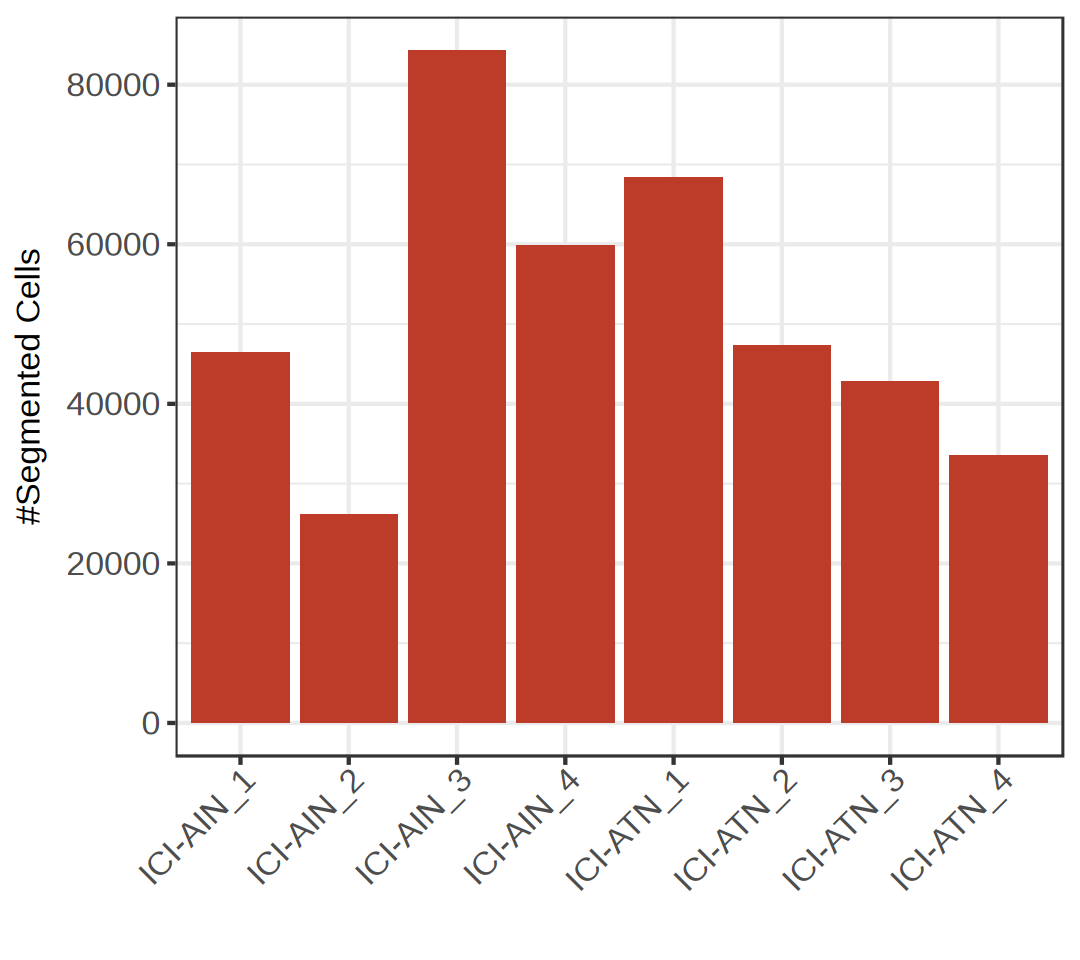

In [48]:
p1

In [49]:
mols = colSums(orig.sub[['RNA']]$counts)
mols_baysor = colSums(baysor[['RNA']]$counts)

In [50]:
mols_num = colSums(orig.sub[['RNA']]$counts > 0)
mols_num_baysor = colSums(baysor[['RNA']]$counts > 0)

In [51]:
orig.sub$mols_num = mols_num
baysor$mols_num_baysor = mols_num_baysor
orig.sub$mols_counts = mols
baysor$mols_counts_baysor = mols_baysor

In [52]:
my_sample_col

,sample,group,patient_id,group_simple,patient
,<chr>,<chr>,<chr>,<chr>,<int>
BS21-N65682A2,Case,ICI-AIN,AIN_1,AIN,1
BS22-T41795A1,Case,ICI-AIN,AIN_2,AIN,2
BS23_49001A1,Case,ICI-AIN,AIN_3,AIN,3
BS23_52206A2,Case,ICI-AIN,AIN_4,AIN,4
BS22_12012A1,Control,ICI-ATN,ATN_1,ATN,1
BS2_61615A1,Control,ICI-ATN,ATN_2,ATN,2
BS24-R31519A2,Control,ICI-ATN,ATN_3,ATN,3
BS24-M35359A1,Control,ICI-ATN,ATN_4,ATN,4


In [53]:
orig.cnt = orig.sub@meta.data %>% group_by(sample) %>% summarise(feature_counts=sum(mols_counts))
baysor.cnt = baysor@meta.data %>% group_by(sample) %>% summarise(feature_counts=sum(mols_counts_baysor))

In [54]:
orig.cnt

sample,feature_counts
<chr>,<dbl>
output-XETG00150__0018462__BS22_12012A1__20240803__183643,9387414
output-XETG00150__0018462__BS23_49001A1__20240803__183643,9998431
output-XETG00150__0018462__BS23_52206A2__20240803__183643,15574220
output-XETG00150__0018462__BS2_61615A1__20240803__183643,5179678
output-XETG00392__0045655__BS21-N65682A2__20241025__201009,6234033
output-XETG00392__0045655__BS22-T41795A1__20241025__201009,3899374
output-XETG00392__0045655__BS24-M35359A1__20241025__201009,7692798
output-XETG00392__0045655__BS24-R31519A2__20241025__201009,10378594


In [55]:
joint.cnt = baysor.cnt %>% left_join(orig.cnt, suffix = c(".baysor", ".10x"), by='sample')
joint.cnt = joint.cnt %>% pivot_longer(cols=c(feature_counts.baysor, feature_counts.10x))
joint.cnt = joint.cnt %>% mutate(sample=str_extract(sample, "_(BS\\d*[_-].*A\\d)_", group = 1))

In [56]:
joint.cnt

sample,name,value
<chr>,<chr>,<dbl>
BS22_12012A1,feature_counts.baysor,13192156
BS22_12012A1,feature_counts.10x,9387414
BS23_49001A1,feature_counts.baysor,12123827
BS23_49001A1,feature_counts.10x,9998431
BS23_52206A2,feature_counts.baysor,19996997
BS23_52206A2,feature_counts.10x,15574220
BS2_61615A1,feature_counts.baysor,6886485
BS2_61615A1,feature_counts.10x,5179678
BS21-N65682A2,feature_counts.baysor,7877419


In [57]:
joint.cnt = joint.cnt %>% left_join(my_sample_col %>% rownames_to_column() %>% select(-"sample") %>% rename(sample=rowname), by='sample') %>% 
  mutate(name = case_when(
      name == 'feature_counts.baysor' ~ "baysor",
      name == 'feature_counts.10x' ~ '10x'
      )) %>% mutate(patient_id = case_when(
      grepl("AIN", patient_id) ~ gsub("AIN", "ICI-AIN", patient_id),
      grepl("ATN", patient_id) ~ gsub("ATN", "ICI-ATN", patient_id),      
  ))

In [58]:
joint.cnt

sample,name,value,group,patient_id,group_simple,patient
<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>
BS22_12012A1,baysor,13192156,ICI-ATN,ICI-ATN_1,ATN,1
BS22_12012A1,10x,9387414,ICI-ATN,ICI-ATN_1,ATN,1
BS23_49001A1,baysor,12123827,ICI-AIN,ICI-AIN_3,AIN,3
BS23_49001A1,10x,9998431,ICI-AIN,ICI-AIN_3,AIN,3
BS23_52206A2,baysor,19996997,ICI-AIN,ICI-AIN_4,AIN,4
BS23_52206A2,10x,15574220,ICI-AIN,ICI-AIN_4,AIN,4
BS2_61615A1,baysor,6886485,ICI-ATN,ICI-ATN_2,ATN,2
BS2_61615A1,10x,5179678,ICI-ATN,ICI-ATN_2,ATN,2
BS21-N65682A2,baysor,7877419,ICI-AIN,ICI-AIN_1,AIN,1


In [59]:
joint.cnt = joint.cnt %>% mutate(patient2=sample_translator[match(sample, names(sample_translator))])
joint.cnt = joint.cnt %>% unite("patient_id2", c(group, patient2), remove=F)
joint.cnt = joint.cnt %>% filter(name=='baysor')

In [60]:
p2 = joint.cnt |> 
    ggplot(aes(x=patient_id, y=value, fill=name)) + geom_bar(stat='identity', position='dodge') + scale_fill_nejm() + get_theme(size=20) + ylab("#Transcripts Counts") + xlab("") + theme(legend.position='none')

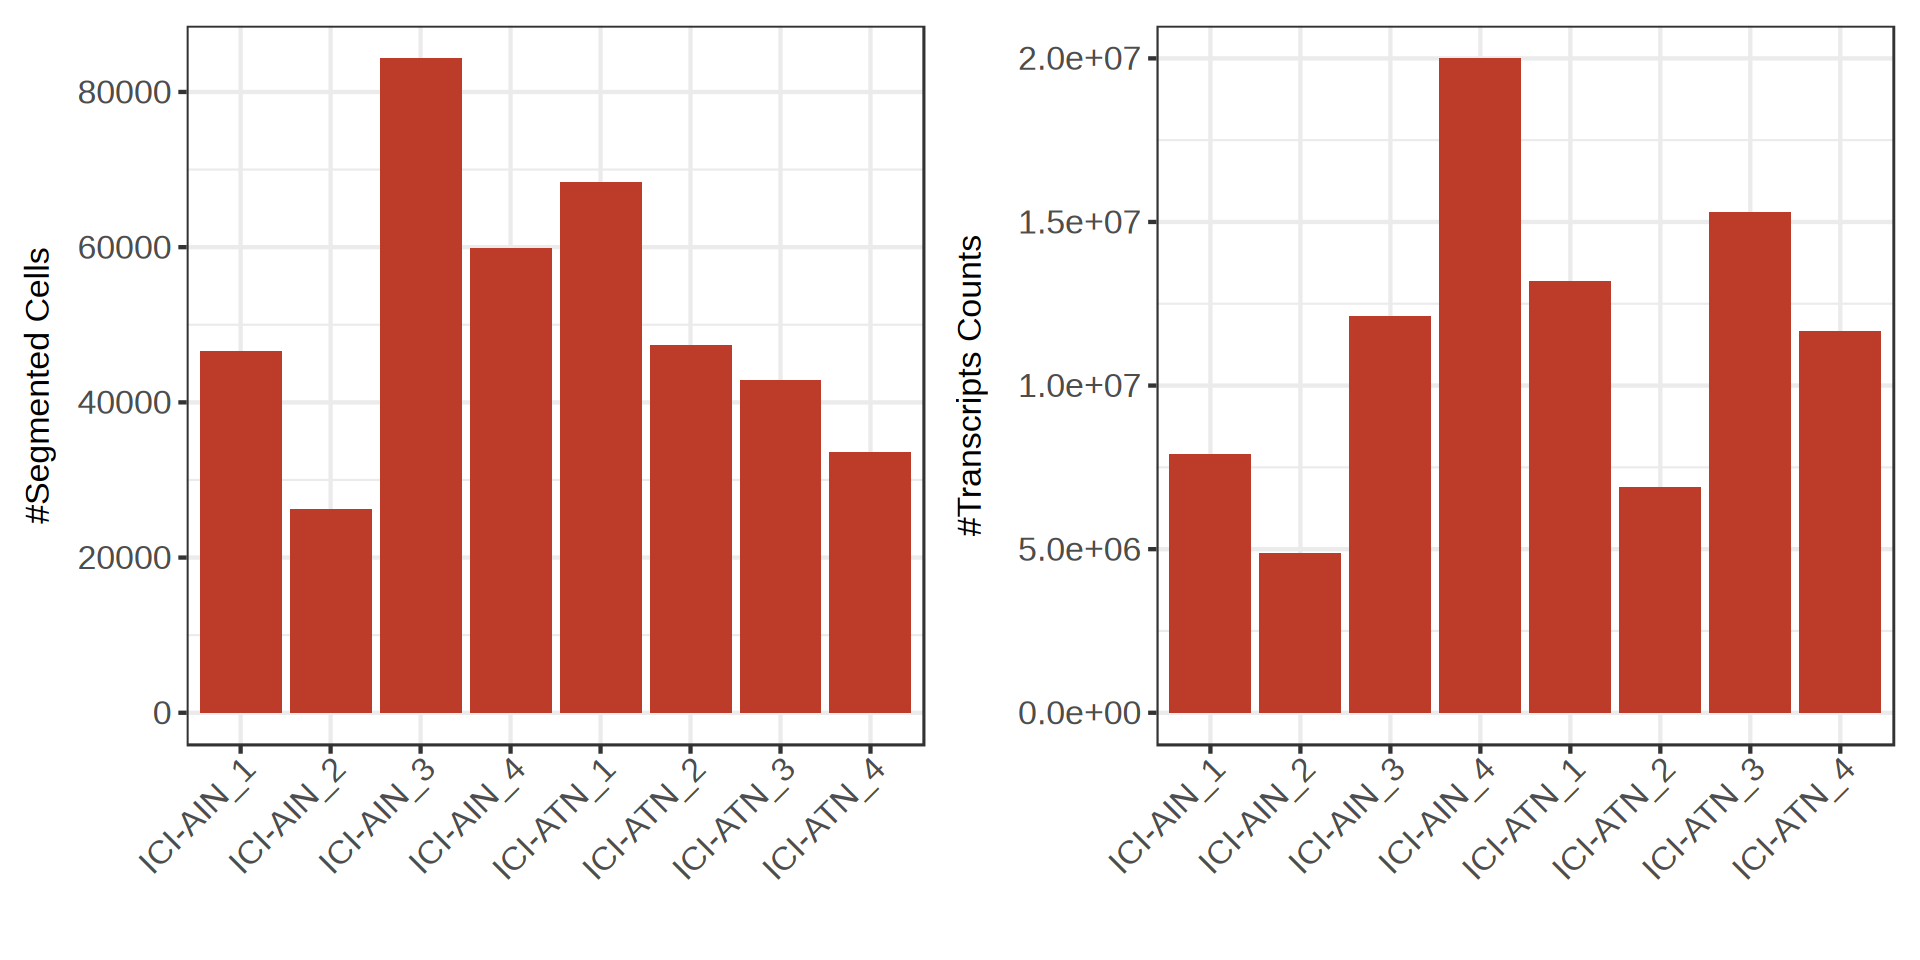

In [61]:
fig.size(8, 16)
p1 | p2

# Fig.1b QC of xenium based on SOPA

In [62]:
table(obj.merge$lennard_label)


                       B                     cDC1       Collecting Duct-IC 
                    2750                     1591                     7037 
                   18723                     1265                     4970 
             Endothelial            Immune (LowQ)     Inflammatory Myeloid 
                   28441                    14799                    21823 
               Mast cell                 Monocyte                 Parietal 
                     785                     1052                      537 
                     pDC                   Plasma                 Podocyte 
                    1352                     2794                     4664 
    Proliferating T cell          Proximal Tubule             Regulatory T 
                    2420                    92359                     3130 
                  Stroma                        T     Thick Ascending Limb 
                   47998                    25021                    23119 
     Thin A

In [63]:
names(celltype_colors)

[1] "T"                        "Regulatory T"            
 [3] "Proliferating T cell"     "Immune (LowQ)"           
 [5] "B"                        "Plasma"                  
 [7] "Tissue Myeloid"           "Monocyte"                
 [9] "Inflammatory Myeloid"     "cDC1"                    
[11] "pDC"                      "Mast cell"               
[13] "Endothelial"              "Podocyte"                
[15] "Parietal"                 "Proximal Tubule"         
[17] "Thick Ascending Limb"     "Thin Ascending Limb"     
[19] "Thin Descending Limb"     "Stroma"                  
[21] "Distal Convoluted Tubule" "Collecting Duct-IC"      
[23] "Collecting Duct-PC"       "Connecting Tubule"

In [64]:
obj.merge@meta.data = obj.merge@meta.data %>% mutate(lennard_label = factor(lennard_label, levels=names(celltype_colors)))

In [65]:
table(obj.merge@meta.data$lennard_label)


                       T             Regulatory T     Proliferating T cell 
                   25021                     3130                     2420 
           Immune (LowQ)                        B                   Plasma 
                   14799                     2750                     2794 
          Tissue Myeloid                 Monocyte     Inflammatory Myeloid 
                   18596                     1052                    21823 
                    cDC1                      pDC                Mast cell 
                    1591                     1352                      785 
             Endothelial                 Podocyte                 Parietal 
                   28441                     4664                      537 
         Proximal Tubule     Thick Ascending Limb      Thin Ascending Limb 
                   92359                    23119                     4321 
    Thin Descending Limb                   Stroma Distal Convoluted Tubule 
           

In [66]:
names(celltype_colors)

[1] "T"                        "Regulatory T"            
 [3] "Proliferating T cell"     "Immune (LowQ)"           
 [5] "B"                        "Plasma"                  
 [7] "Tissue Myeloid"           "Monocyte"                
 [9] "Inflammatory Myeloid"     "cDC1"                    
[11] "pDC"                      "Mast cell"               
[13] "Endothelial"              "Podocyte"                
[15] "Parietal"                 "Proximal Tubule"         
[17] "Thick Ascending Limb"     "Thin Ascending Limb"     
[19] "Thin Descending Limb"     "Stroma"                  
[21] "Distal Convoluted Tubule" "Collecting Duct-IC"      
[23] "Collecting Duct-PC"       "Connecting Tubule"

In [67]:
p3 = VlnPlot_scCustom(obj.merge, features=c("nCount_RNA"), group.by="lennard_label", pt.size = 0) + NoLegend() + scale_fill_manual(values=celltype_colors)
p4 = VlnPlot_scCustom(obj.merge, features=c("nFeature_RNA"), group.by="lennard_label", pt.size = 0) + NoLegend() + scale_fill_manual(values=celltype_colors) 

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already presen

In [68]:
table(obj.merge@meta.data$lennard_label)


                       T             Regulatory T     Proliferating T cell 
                   25021                     3130                     2420 
           Immune (LowQ)                        B                   Plasma 
                   14799                     2750                     2794 
          Tissue Myeloid                 Monocyte     Inflammatory Myeloid 
                   18596                     1052                    21823 
                    cDC1                      pDC                Mast cell 
                    1591                     1352                      785 
             Endothelial                 Podocyte                 Parietal 
                   28441                     4664                      537 
         Proximal Tubule     Thick Ascending Limb      Thin Ascending Limb 
                   92359                    23119                     4321 
    Thin Descending Limb                   Stroma Distal Convoluted Tubule 
           

In [69]:
sum(is.na(obj.merge@meta.data$lennard_label))

[1] 0

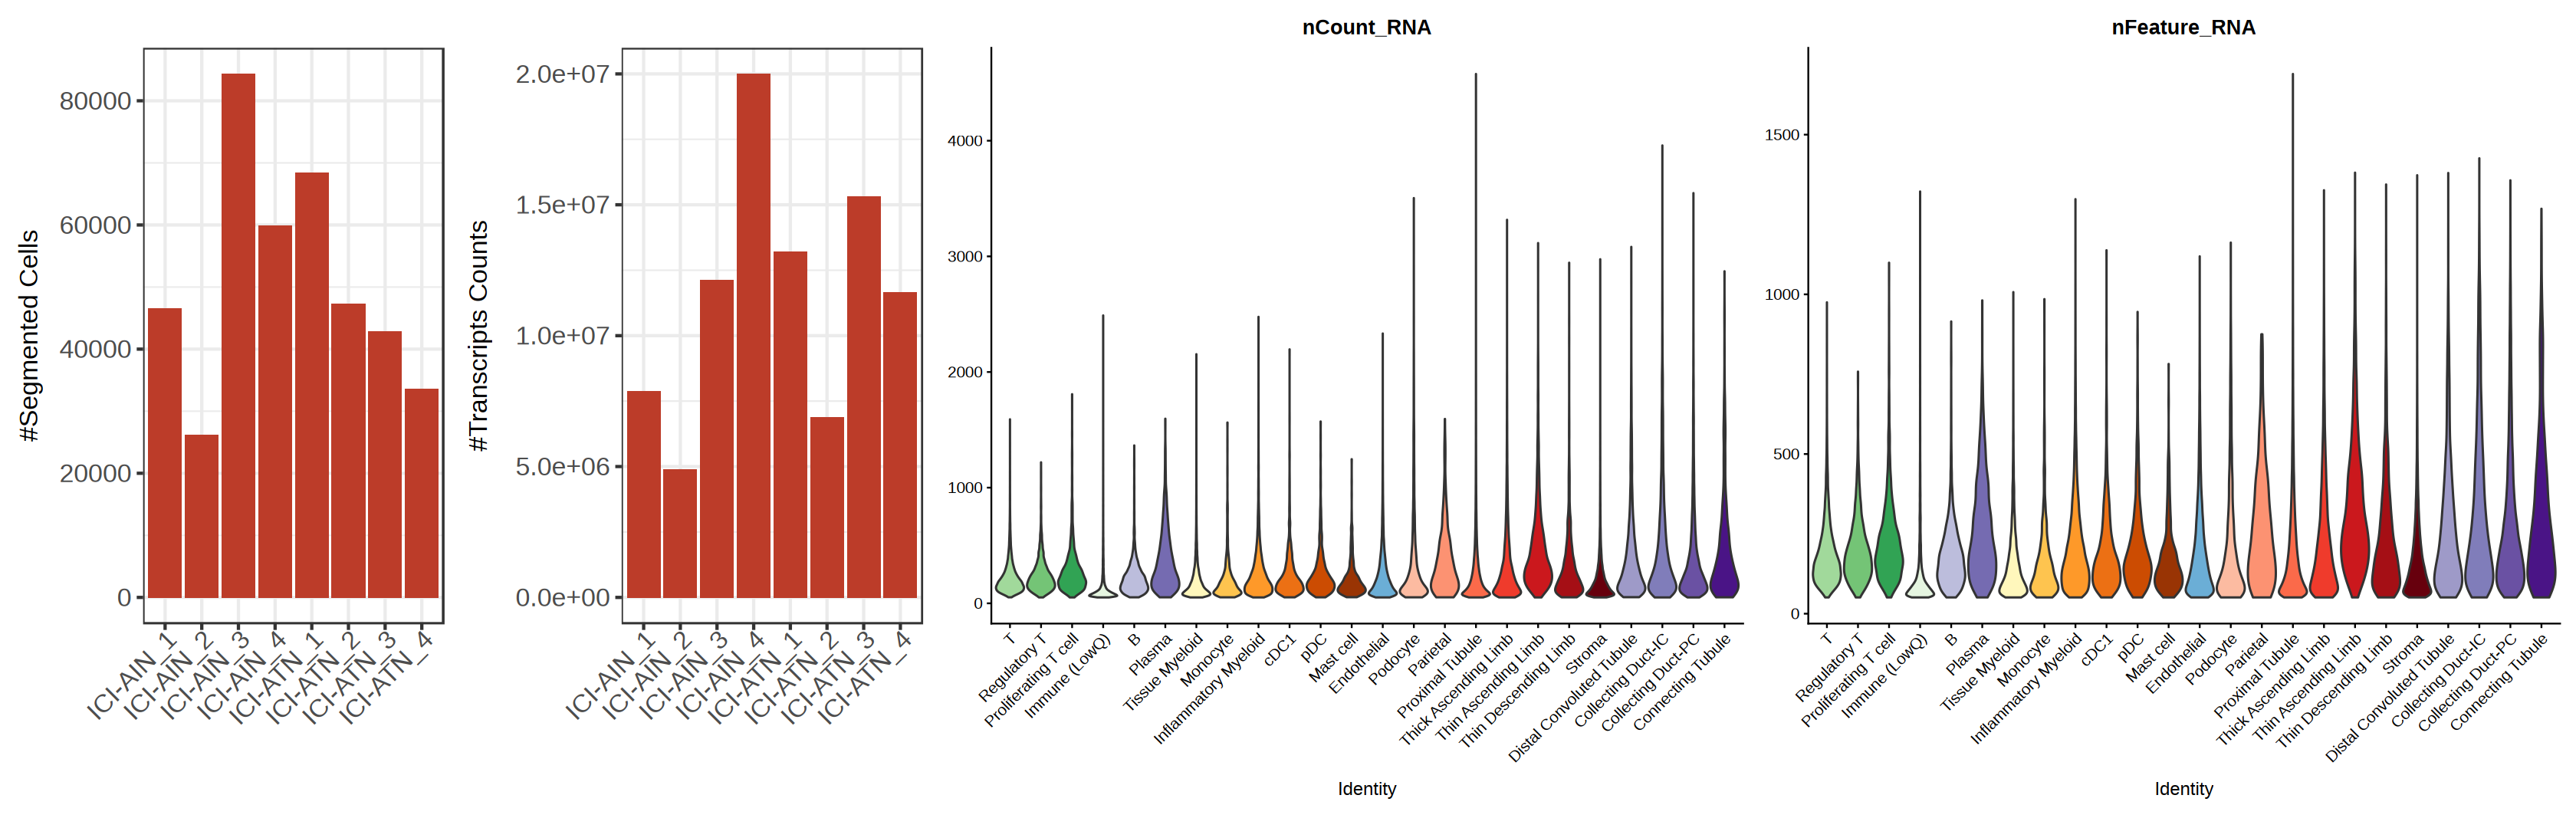

In [70]:
library(patchwork)
fig.size(9, 28)
p1 + p2 + p3 + p4 + plot_layout(ncol=4, widths = c(1, 1, 2.5, 2.5), guides='collect') # & theme(legend.position='bottom')

# Fig.1c

In [71]:
# orig.merge@meta.data  = orig.merge@meta.data %>% mutate(cell_label=case_when(
#     cell_label %in% c("Basophil") ~ "Mast", 
#     cell_label %in% c("Interstitial") ~ "Stroma",  
#     .default = cell_label 
# )
#                                                      )

In [72]:
table(orig.merge$tech)


    sc xenium 
225177 332341 

In [73]:
head(orig.merge)

,orig.ident,nCount_RNA,nFeature_RNA,region,cell_id,slide,area,sample,scDblFinder.class,doublet_density,⋯,cell_type,celltype,PrimaryAdjudicatedCategory,diabetes_history,hypertension,eGFR,is_primary_data,disease_category,fine_ids,sample_ids
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
3,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,107,97,baysor_boundaries,aaaaaaac-1,morphology_focus,47.75371,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,0.04,⋯,monocyte,MON,NA,NA,NA,NA,NA,NA,kidney interstitial alternatively activated macrophage,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
4,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,87,73,baysor_boundaries,aaaaaaad-1,morphology_focus,114.91816,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,0.48,⋯,epithelial cell of proximal tubule,PT-S1/S2,NA,NA,NA,NA,NA,NA,epithelial cell of proximal tubule,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
5,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,133,114,baysor_boundaries,aaaaaaae-1,morphology_focus,45.60825,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,0.52,⋯,epithelial cell of proximal tubule,PT-S1/S2,NA,NA,NA,NA,NA,NA,epithelial cell of proximal tubule,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
6,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,172,154,baysor_boundaries,aaaaaaaf-1,morphology_focus,78.27605,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,1.52,⋯,endothelial cell,EC-PTC,NA,NA,NA,NA,NA,NA,endothelial cell,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
7,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,372,289,baysor_boundaries,aaaaaaag-1,morphology_focus,113.95260,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,doublet,1.38,⋯,monocyte,MON,NA,NA,NA,NA,NA,NA,natural killer cell,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
9,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,65,59,baysor_boundaries,aaaaaaai-1,morphology_focus,57.63673,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,0.16,⋯,T cell,T,NA,NA,NA,NA,NA,NA,endothelial cell,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
10,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,958,637,baysor_boundaries,aaaaaaaj-1,morphology_focus,145.48668,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,1.10,⋯,kidney interstitial cell,VSMC,NA,NA,NA,NA,NA,NA,kidney interstitial cell,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
11,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,115,105,baysor_boundaries,aaaaaaak-1,morphology_focus,51.94543,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,1.92,⋯,mature NK T cell,NKT,NA,NA,NA,NA,NA,NA,cytotoxic T cell,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad
12,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,163,148,baysor_boundaries,aaaaaaal-1,morphology_focus,56.53088,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad,singlet,1.14,⋯,endothelial cell,EC-GC,NA,NA,NA,NA,NA,NA,endothelial cell,output-XETG00392__0045655__BS21-N65682A2__20241025__201009_orig_seg.h5ad


In [74]:
colnames(head(orig.merge))

[1] "orig.ident"                         "nCount_RNA"                        
 [3] "nFeature_RNA"                       "region"                            
 [5] "cell_id"                            "slide"                             
 [7] "area"                               "sample"                            
 [9] "scDblFinder.class"                  "doublet_density"                   
[11] "humap_fgraph_res.0.8"               "seurat_clusters"                   
[13] "tech"                               "percent.mt"                        
[15] "SpecimenID"                         "LibraryID"                         
[17] "SampleType"                         "SampleID"                          
[19] "Run"                                "clusterNumber"                     
[21] "subclass.l1"                        "subclass.l2"                       
[23] "dataSource"                         "diseasetype"                       
[25] "umap_1"                             "umap_2"                            
[27] "Age"                                "Gender"                            
[29] "Race"                               "clusterClass"                      
[31] "organism"                           "tissue"                            
[33] "assay"                              "EnrollementCategory"               
[35] "disease"                            "donor_id"                          
[37] "suspension_type"                    "tissue_type"                       
[39] "development_stage_ontology_term_id" "development_stage"                 
[41] "cell_type"                          "celltype"                          
[43] "PrimaryAdjudicatedCategory"         "diabetes_history"                  
[45] "hypertension"                       "eGFR"                              
[47] "is_primary_data"                    "disease_category"                  
[49] "fine_ids"                           "sample_ids"

In [75]:
p11=DimPlot_scCustom(subset(orig.merge, subset = tech=='sc'), raster = TRUE, label=T, repel=T, label.size=6,
    raster.dpi = c(300, 300), group.by="cell_type", seed=99) +ggplot2::theme(legend.position = "right",         
                                                                             axis.line = element_line(arrow = arrow(type = "closed", length = unit(10, 'pt'))))+
    scale_x_continuous(breaks = NULL) +
    scale_y_continuous(breaks = NULL) + NoLegend()+ggtitle("KPMP scRNA-seq")+xlab("")+ylab("") #+scale_color_manual(values=celltype_colors)

p12=DimPlot_scCustom(subset(orig.merge, subset = tech=='xenium'), raster = TRUE,        # enable rasterization
  raster.dpi = c(300, 300),  group.by="cell_type", seed=99) +ggplot2::theme(legend.position = "none") + ggtitle("Xenium 8 patients")+scale_x_continuous(breaks = NULL)+ scale_y_continuous(breaks = NULL)+xlab("")+ylab("") 


In [76]:
# p11 | p12

In [77]:
head(sample_mat)

,B,Collecting Duct-IC,Collecting Duct-PC,Connecting Tubule,Distal Convoluted Tubule,Endothelial,Immune (LowQ),Inflammatory Myeloid,Mast cell,Monocyte,⋯,Proximal Tubule,Regulatory T,Stroma,T,Thick Ascending Limb,Thin Ascending Limb,Thin Descending Limb,Tissue Myeloid,cDC1,pDC
BS22_12012A1,0.0029817864,0.032533759,0.05617914,0.004596129,0.014548079,0.09479042,0.01462405,0.03441399,0.001367443,0.002165119,⋯,0.3637210,0.0038934154,0.19119518,0.02772871,0.07055628,0.012420945,0.006685279,0.03686400,0.001918219,0.0016903120
BS23_49001A1,0.0115354077,0.009767644,0.05878564,0.002352025,0.008479274,0.04067355,0.09782625,0.09721203,0.003460622,0.004868841,⋯,0.1839074,0.0179772588,0.06200656,0.17345059,0.06104777,0.011070995,0.005707780,0.09497985,0.011700199,0.0093931177
BS23_52206A2,0.0033898305,0.001984719,0.02567841,0.001159217,0.006885044,0.10069377,0.05861070,0.10749100,0.001334856,0.004478792,⋯,0.1589708,0.0129094582,0.16724335,0.09342232,0.08736278,0.019601300,0.017265303,0.07808905,0.003811364,0.0040396944
BS2_61615A1,0.0008613009,0.031600832,0.07389367,0.006474606,0.021740422,0.09774280,0.01517672,0.02631423,0.001306801,0.001128601,⋯,0.3819127,0.0005049005,0.17793288,0.01378081,0.08452628,0.014731215,0.008375408,0.02307692,0.001633502,0.0003861004
BS21-N65682A2,0.0343178775,0.003552010,0.04868985,0.002868931,0.013524960,0.06505642,0.04822536,0.08511162,0.005191399,0.004726905,⋯,0.2633405,0.0181425722,0.14948496,0.08869095,0.04210498,0.007896391,0.004289735,0.06732424,0.006748818,0.0074045739
BS22-T41795A1,0.0121876618,0.002682227,0.05439744,0.001976378,0.012422945,0.10738318,0.04950355,0.09637194,0.003246906,0.004046868,⋯,0.1445579,0.0105406804,0.18610889,0.07806691,0.11453579,0.020469625,0.011152416,0.06616159,0.006493812,0.0046115477


In [78]:
sample_mat = sample_mat[rownames(my_sample_col),]
rownames(sample_mat) = my_sample_col$patient_id

In [79]:
sample_mat <- scale(sample_mat)

In [80]:
head(sample_mat)

,B,Collecting Duct-IC,Collecting Duct-PC,Connecting Tubule,Distal Convoluted Tubule,Endothelial,Immune (LowQ),Inflammatory Myeloid,Mast cell,Monocyte,⋯,Proximal Tubule,Regulatory T,Stroma,T,Thick Ascending Limb,Thin Ascending Limb,Thin Descending Limb,Tissue Myeloid,cDC1,pDC
AIN_1,2.2664994,-0.8705105,-0.48937012,-0.4859245,-0.3747272,-0.9221048,0.3043159,0.6157396,1.9603866,1.0078463,⋯,-0.2285116,1.3070361,-0.03722059,0.4340841,-1.2372483,-1.0838581,-0.94229667,0.5569417,0.6526863,1.1166609
AIN_2,0.3207481,-0.9102264,-0.19723473,-0.8519459,-0.5102889,0.6510032,0.3461143,0.9081514,0.6004512,0.6266266,⋯,-1.2448680,0.2921215,0.84203255,0.2415075,1.8516300,1.5338294,0.69645553,0.5177954,0.5860780,0.3090037
AIN_3,0.2634001,-0.5866927,0.02736944,-0.6978992,-0.9954101,-1.8283140,1.9263257,0.9299672,0.7499196,1.0874137,⋯,-0.9081768,1.2849654,-2.13736810,1.9704800,-0.4294153,-0.4229205,-0.60367914,1.4881026,1.9460012,1.6916865
AIN_4,-0.4527821,-0.9420760,-1.66718154,-1.1870502,-1.1915204,0.4023860,0.6439290,1.1968950,-0.7367950,0.8687571,⋯,-1.1215453,0.6083726,0.38911594,0.5198474,0.6928123,1.3530482,2.15616270,0.9193914,-0.1145851,0.1436414
ATN_1,-0.4886585,0.4528517,-0.10604096,0.2223712,-0.2488706,0.1829831,-0.7944882,-0.7007935,-0.7140037,-0.4282576,⋯,0.6303876,-0.5953427,0.96414235,-0.6709481,-0.0239162,-0.1418675,-0.37026028,-0.4686511,-0.6090799,-0.5357276
ATN_2,-0.6750976,0.4102525,0.80065489,0.9927038,0.6358781,0.2927106,-0.7764153,-0.9111310,-0.7564155,-1.0093159,⋯,0.7860439,-1.0477372,0.64574604,-0.9237748,0.5718473,0.3391197,0.03332876,-0.9328602,-0.6834490,-0.9128655


In [81]:
my_sample_col = my_sample_col %>% rownames_to_column()
my_sample_col = my_sample_col %>% column_to_rownames(var='patient_id')

In [82]:
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))
ht_opt("heatmap_row_names_gp" = gpar(fontsize = 15))
ha1 = rowAnnotation(samples = my_sample_col$group,
                    col=list(samples=c('ICI-AIN'='gray', 'ICI-ATN'='black')),
                    annotation_name_gp = gpar(fontsize = 15),
                    annotation_legend_param = list(
                    samples = list(title_gp = gpar(fontsize = 15), labels_gp = gpar(fontsize = 5), direction = "horizontal")))

colnames(sample_mat)[colnames(sample_mat)=='Immune Cell'] = 'Immune (LowQ)'
colnames(sample_mat) = gsub(" Cell", "", colnames(sample_mat))
sample_mat = sample_mat[, names(celltype_colors)]

In [83]:
sample_mat

,T,Regulatory T,Proliferating T cell,Immune (LowQ),B,Plasma,Tissue Myeloid,Monocyte,Inflammatory Myeloid,cDC1,⋯,Parietal,Proximal Tubule,Thick Ascending Limb,Thin Ascending Limb,Thin Descending Limb,Stroma,Distal Convoluted Tubule,Collecting Duct-IC,Collecting Duct-PC,Connecting Tubule
AIN_1,0.4340841,1.3070361,-0.01822159,0.3043159,2.2664994,0.4438369,0.5569417,1.0078463,0.6157396,0.6526863,⋯,-0.1859111,-0.2285116,-1.2372483,-1.0838581,-0.94229667,-0.03722059,-0.3747272,-0.8705105,-0.48937012,-0.4859245
AIN_2,0.2415075,0.2921215,0.49141221,0.3461143,0.3207481,-0.3937980,0.5177954,0.6266266,0.9081514,0.5860780,⋯,-1.8047344,-1.2448680,1.8516300,1.5338294,0.69645553,0.84203255,-0.5102889,-0.9102264,-0.19723473,-0.8519459
AIN_3,1.9704800,1.2849654,2.24784110,1.9263257,0.2634001,-0.2560156,1.4881026,1.0874137,0.9299672,1.9460012,⋯,-0.1943926,-0.9081768,-0.4294153,-0.4229205,-0.60367914,-2.13736810,-0.9954101,-0.5866927,0.02736944,-0.6978992
AIN_4,0.5198474,0.6083726,-0.20176493,0.6439290,-0.4527821,2.3337129,0.9193914,0.8687571,1.1968950,-0.1145851,⋯,-0.9377189,-1.1215453,0.6928123,1.3530482,2.15616270,0.38911594,-1.1915204,-0.9420760,-1.66718154,-1.1870502
ATN_1,-0.6709481,-0.5953427,-0.39237355,-0.7944882,-0.4886585,-0.4790155,-0.4686511,-0.4282576,-0.7007935,-0.6090799,⋯,0.7068844,0.6303876,-0.0239162,-0.1418675,-0.37026028,0.96414235,-0.2488706,0.4528517,-0.10604096,0.2223712
ATN_2,-0.9237748,-1.0477372,-0.67902427,-0.7764153,-0.6750976,-0.5315512,-0.9328602,-1.0093159,-0.9111310,-0.6834490,⋯,0.4293041,0.7860439,0.5718473,0.3391197,0.03332876,0.64574604,0.6358781,0.4102525,0.80065489,0.9927038
ATN_3,-0.9621662,-1.0312744,-0.75123006,-1.0083303,-0.7388183,-0.5668272,-1.2721085,-1.3357636,-1.2419532,-0.9674372,⋯,1.2521767,0.7952549,-0.5855939,-0.9934573,-0.43392660,-0.30865593,1.0996773,1.8620130,1.80526709,1.7426162
ATN_4,-0.6090300,-0.8181413,-0.69663891,-0.6414510,-0.4952910,-0.5503423,-0.8086113,-0.8173066,-0.7968754,-0.8102143,⋯,0.7343917,1.2914153,-0.8401159,-0.5838938,-0.53578429,-0.35779226,1.5852618,0.5843884,-0.17346406,0.2651287


In [99]:
# # Desired cell size
# cell_width <- unit(2.5, "mm")   # width per column
# cell_height <- unit(3.5, "mm")   # height per row
# # Main heatmap
# ht2 <- Heatmap(
#   t(sample_mat),
#   name = "Expression",
#   col = col_fun,
# #  width = cell_width * ncol(sample_mat),
# #  height = cell_height * nrow(sample_mat),
#   column_names_gp = gpar(fontsize = 15),
#   heatmap_legend_param = list(
#     title_gp = gpar(fontsize = 15),
#     labels_gp = gpar(fontsize = 15),
#     direction = "horizontal"
#   ),cluster_columns = FALSE,
#   column_names_side = "top",
#   right_annotation = ha1)
# ht_plot <- wrap_elements(full=grid.grabExpr(draw(ht2,
#                               merge_legend = TRUE, heatmap_legend_side = "bottom",
#                               annotation_legend_list = NULL)))

In [100]:
# ht_plot

# Supp Fig. 1e

In [86]:
table(obj.merge$sample_id)


  BS2_61615A1 BS21-N65682A2  BS22_12012A1 BS22-T41795A1  BS23_49001A1 
        33670         36599         52653         21251         66751 
 BS23_52206A2 BS24-M35359A1 BS24-R31519A2 
        56935         27870         36612 

In [87]:
obj.merge@meta.data$condition = factor(str_trim(orig.merge.xen@meta.data$case_ctrl), levels=c("Control", "Case"))

In [88]:
# head(obj.merge@meta.data[, c("sample_id", "cell_label", "case_ctrl")])

In [89]:
# library(sccomp)

# res = obj.merge %>% sccomp_estimate(,
#       formula_composition = ~ condition,
#       sample = "sample_id", cell_group = "lennard_label",
#       cores = 1, verbose=T
#     )

# #res = res |>  sccomp_test()

In [90]:
p2e=FeaturePlot_scCustom(subset(orig.merge, subset = tech=='xenium'), 
                         raster = TRUE, features=markers[seq(1, length(markers), 2)],
    raster.dpi = c(150, 150)) #+scale_x_continuous(breaks = NULL)+ scale_y_continuous(breaks = NULL)+xlab("")+ylab("") 


NOTE: FeaturePlot_scCustom uses a specified `na_cutoff` when plotting to
color cells with no expression as background color separate from color scale.
Please ensure `na_cutoff` value is appropriate for feature being plotted.
Default setting is appropriate for use when plotting from 'RNA' assay.
When `na_cutoff` not appropriate (e.g., module scores) set to NULL to
plot all cells in gradient color palette.

-----This message will be shown once per session.-----


In [91]:
suppfig1e = p2e
#suppfig1e

In [92]:
ggsave("SuppFig2.pdf", width=24, height=32)

In [93]:
getwd()

[1] "/data/wei/qq06/xenium/phaseZ2_refactor_figs"

# Assemble figures

Warning message:
“ggrepel: 22 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


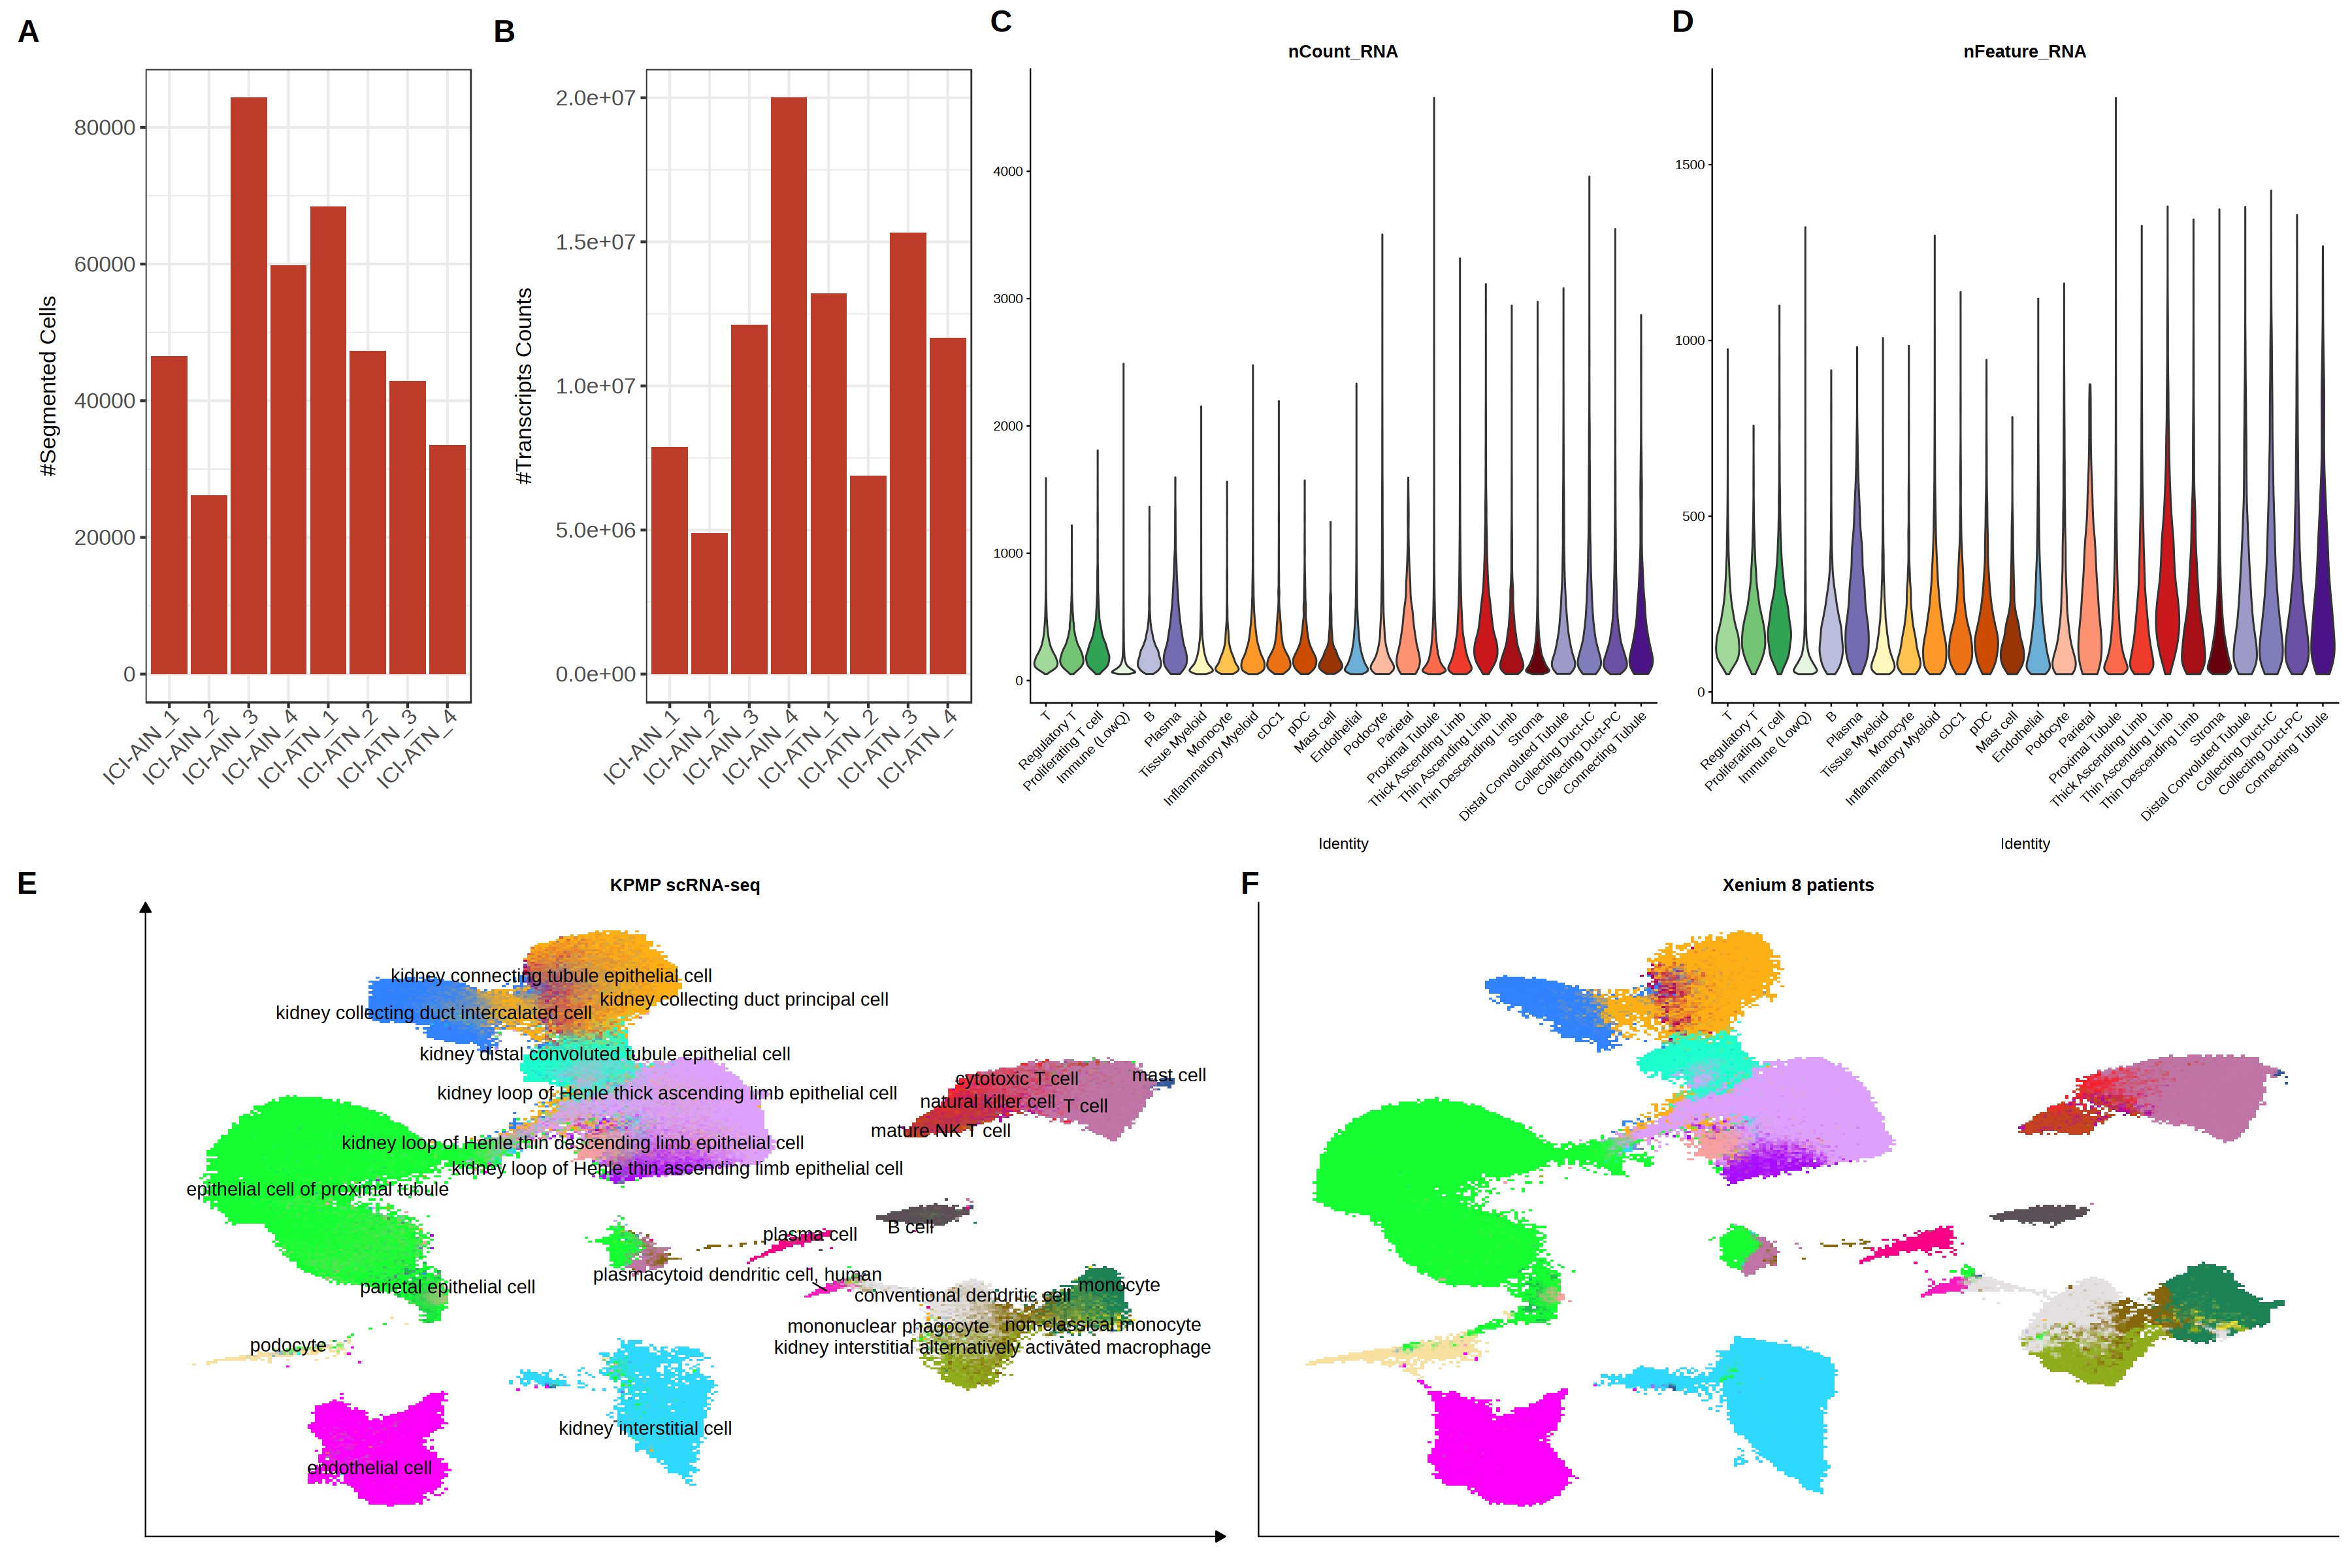

In [94]:
library(patchwork)
fig.size(20, 30)
(p1 + p2 + p3 + p4 + plot_layout(ncol=4, widths = c(1.3, 1.3, 2.5, 2.5))) / (p11 + p12 + plot_layout(ncol=2, widths = c(2.5, 2.5))) + plot_layout(nrow=2) +
 plot_annotation(
    tag_levels = list(c("A", "B", "C", "D", "E", "F")), 
 ) &  theme(plot.tag = element_text(face = "bold", size = 28))

In [95]:
ggsave("SuppFig1.pdf", width=22, height=18)

In [96]:
getwd()

[1] "/data/wei/qq06/xenium/phaseZ2_refactor_figs"